Resampling Filter

In [6]:
from pathlib import Path
import pandas as pd
from imblearn.over_sampling import RandomOverSampler, SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [7]:
BASE = Path('..').resolve()
PROC = BASE / 'data' / 'processed'
IMB = BASE / 'data' / 'imbalanced'
REPORTS = BASE / 'reports'
FIGS = REPORTS / 'figures'
for path in [IMB, REPORTS, FIGS]:
    path.mkdir(parents=True, exist_ok=True)

FEATURES = [
    'inter_api_access_duration(sec)', 'api_access_uniqueness', 'sequence_length(count)',
    'vsession_duration(min)', 'ip_type', 'num_sessions', 'num_users',
    'num_unique_apis', 'source', 'failed_auth_count', 'token_reuse_ratio',
    'status_4xx_ratio', 'status_5xx_ratio'
]
TARGET = 'attack_class'
CAT_COLS = ['ip_type', 'source']
NUM_COLS = [c for c in FEATURES if c not in CAT_COLS]

In [11]:
X_train = pd.read_csv(PROC / 'X_train.csv')
X_test = pd.read_csv(PROC / 'X_test.csv')

y_train_df = pd.read_csv(PROC / 'y_train.csv')
y_test_df = pd.read_csv(PROC / 'y_test.csv')

y_train = y_train_df[TARGET] if TARGET in y_train_df.columns else y_train_df.iloc[:, 0]
y_test = y_test_df[TARGET] if TARGET in y_test_df.columns else y_test_df.iloc[:, 0]

print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)
print('')
print('X_train columns:', list(X_train.columns))
print('y_train columns:', list(y_train_df.columns))
print('X_test columns :', list(X_test.columns))
print('y_test columns :', list(y_test_df.columns))
print('')
print('y_train class distribution:')
print(y_train.value_counts())
print('')
print('y_test class distribution:')
print(y_test.value_counts())

missing_feature_cols = [c for c in FEATURES if c not in X_train.columns]
if missing_feature_cols:
    raise ValueError(f'Missing expected feature columns in X_train: {missing_feature_cols}')

if X_train.empty or X_test.empty or y_train.empty or y_test.empty:
    raise ValueError('One or more input datasets are empty. Re-run 01_preprocessing notebook.')

X_train shape: (4800, 13)
X_test shape : (1200, 13)
y_train shape: (4800,)
y_test shape : (1200,)

X_train columns: ['inter_api_access_duration(sec)', 'api_access_uniqueness', 'sequence_length(count)', 'vsession_duration(min)', 'ip_type', 'num_sessions', 'num_users', 'num_unique_apis', 'source', 'failed_auth_count', 'token_reuse_ratio', 'status_4xx_ratio', 'status_5xx_ratio']
y_train columns: ['attack_class']
X_test columns : ['inter_api_access_duration(sec)', 'api_access_uniqueness', 'sequence_length(count)', 'vsession_duration(min)', 'ip_type', 'num_sessions', 'num_users', 'num_unique_apis', 'source', 'failed_auth_count', 'token_reuse_ratio', 'status_4xx_ratio', 'status_5xx_ratio']
y_test columns : ['attack_class']

y_train class distribution:
attack_class
normal         2542
bruteforce      854
flood           754
token_abuse     650
Name: count, dtype: int64

y_test class distribution:
attack_class
normal         635
bruteforce     214
flood          188
token_abuse    163
Name: co

In [12]:
def make_preprocessor(scaling='none'):
    if scaling == 'minmax':
        num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', MinMaxScaler())])
    elif scaling == 'standard':
        num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    else:
        num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median'))])

    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    return ColumnTransformer([
        ('num', num_pipe, NUM_COLS),
        ('cat', cat_pipe, CAT_COLS)
    ])

categorical_feature_indices = [FEATURES.index(col) for col in CAT_COLS]

samplers = {
    'none': None,
    'oversampling': RandomOverSampler(random_state=42),
    'undersampling': RandomUnderSampler(random_state=42),
    'smote': SMOTENC(categorical_features=categorical_feature_indices, random_state=42)
}

print('Enabled Stage A resampling methods:', list(samplers.keys()))


Enabled Stage A resampling methods: ['none', 'oversampling', 'undersampling', 'smote']


In [19]:
resampling_metrics_rows = []

for name, sampler in samplers.items():
    if sampler is None:
        Xr, yr = X_train.copy(), y_train.copy()
    else:
        Xr, yr = sampler.fit_resample(X_train, y_train)

    # Persist canonical schema for downstream stages
    Xr_df = pd.DataFrame(Xr, columns=FEATURES) if not isinstance(Xr, pd.DataFrame) else Xr[FEATURES].copy()
    Xr_df.to_csv(IMB / f'X_{name}.csv', index=False)
    pd.DataFrame({TARGET: yr}).to_csv(IMB / f'y_{name}.csv', index=False)

    # Evaluate with explicit preprocessing inside pipeline
    clf = Pipeline([
        ('preprocessor', make_preprocessor('none')),
        ('model', RandomForestClassifier(n_estimators=220, random_state=42, class_weight='balanced'))
    ])
    clf.fit(Xr_df, yr)
    yp = clf.predict(X_test)

    resampling_metrics_rows.append({
        'stage': 'A_resampling_filter',
        'resampling': name,
        'model': 'RandomForest',
        'accuracy': round(accuracy_score(y_test, yp), 4),
        'macro_precision': round(precision_score(y_test, yp, average='macro', zero_division=0), 4),
        'macro_recall': round(recall_score(y_test, yp, average='macro', zero_division=0), 4),
        'macro_f1': round(f1_score(y_test, yp, average='macro', zero_division=0), 4),
    })

resampling_results_df = pd.DataFrame(resampling_metrics_rows).sort_values(['macro_f1', 'macro_recall'], ascending=False)
resampling_results_df.to_csv(REPORTS / '02_resampling_results.csv', index=False)

best_two_resampling_methods = resampling_results_df.head(2)['resampling'].tolist()
pd.DataFrame([{'best_two_resampling_methods': ','.join(best_two_resampling_methods)}]).to_csv(REPORTS / '02_resampling_top2_resampling.csv', index=False)

print('Resampling performance leaderboard:')
print(resampling_results_df)
print('')
print('Best two resampling methods:', best_two_resampling_methods)


Resampling performance leaderboard:
                 stage     resampling         model  accuracy  \
2  A_resampling_filter  undersampling  RandomForest    0.9983   
1  A_resampling_filter   oversampling  RandomForest    0.9967   
0  A_resampling_filter           none  RandomForest    0.9958   
3  A_resampling_filter          smote  RandomForest    0.9942   

   macro_precision  macro_recall  macro_f1  
2           0.9973        0.9973    0.9973  
1           0.9962        0.9941    0.9951  
0           0.9958        0.9925    0.9941  
3           0.9935        0.9895    0.9914  

Best two resampling methods: ['undersampling', 'oversampling']


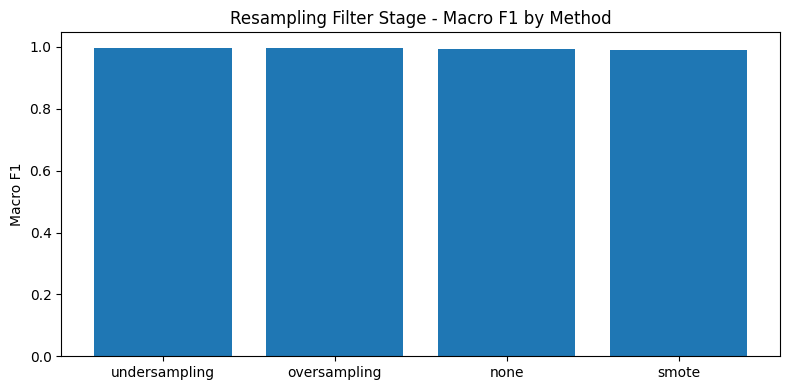

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(resampling_results_df['resampling'], resampling_results_df['macro_f1'])
plt.title('Resampling Filter Stage - Macro F1 by Method')
plt.ylabel('Macro F1')
plt.tight_layout()
plt.savefig(FIGS / '02_resampling_macro_f1.png', dpi=160)
plt.show()

Resampled Class Distribution Plot


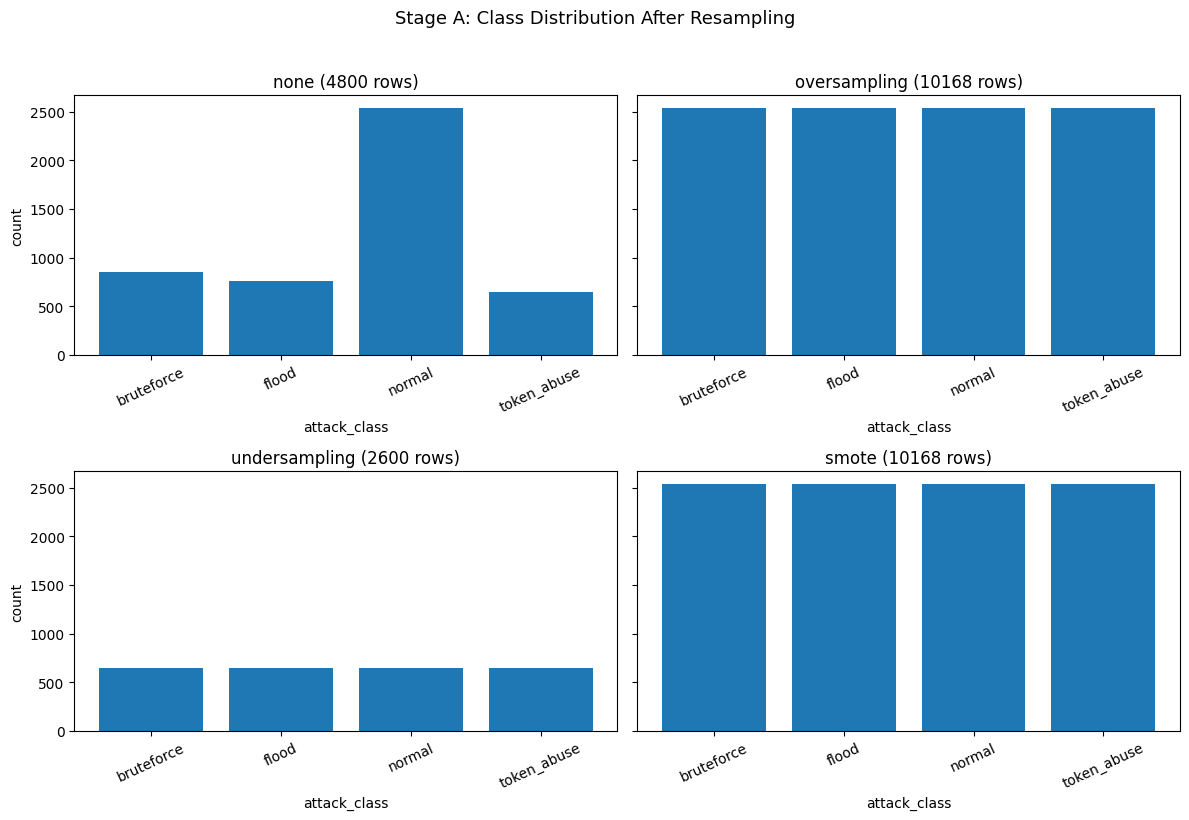

Saved: reports/figures/02_resampled_class_distributions.png


In [21]:
resampling_order = ['none', 'oversampling', 'undersampling', 'smote']
resampling_labels = {}

for method_name in resampling_order:
    y_path = IMB / f'y_{method_name}.csv'
    if not y_path.exists():
        continue
    y_df = pd.read_csv(y_path)
    y_series = y_df[TARGET] if TARGET in y_df.columns else y_df.iloc[:, 0]
    resampling_labels[method_name] = y_series

if not resampling_labels:
    raise FileNotFoundError('No resampled label files found in data/imbalanced. Run the Stage A resampling cell first.')

all_classes = sorted(set().union(*[set(s.unique()) for s in resampling_labels.values()]))
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes_flat = axes.flatten()

for idx, method_name in enumerate(resampling_order):
    ax = axes_flat[idx]
    if method_name not in resampling_labels:
        ax.axis('off')
        ax.set_title(f'{method_name} (missing)')
        continue

    counts = resampling_labels[method_name].value_counts().reindex(all_classes, fill_value=0)
    ax.bar(counts.index.astype(str), counts.values, color='#1f77b4')
    ax.set_title(f'{method_name} ({int(counts.sum())} rows)')
    ax.set_xlabel('attack_class')
    ax.tick_params(axis='x', rotation=25)

for ax in axes[:, 0]:
    ax.set_ylabel('count')

plt.suptitle('Stage A: Class Distribution After Resampling', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS / 'figures' / '02_resampled_class_distributions.png', dpi=180, bbox_inches='tight')
plt.show()

print('Saved: reports/figures/02_resampled_class_distributions.png')
